In [1]:
import pandas as pd


df = pd.read_csv('data/combined_urban_features.csv')
df


# TO DO HERE CORRELATION AND CHECK HOW OUR FAETURES AND WORKING TOGETHER

,city_name,grid_id,target_style,building_count,building_density,avg_building_area,std_building_area,shape_complexity_ratio,courtyard_index,avg_building_elongation,road_segment_count,total_road_length,avg_road_segment_length,road_density_ratio,building_density_spatial_lag
0,"Copenhagen Municipality, Denmark",203,XIX_Century_Blocks,79,0.208488,625.622141,1125.838332,1.353869,0.156829,2.625779,413,15202.912858,36.810927,0.027166,0.255014
1,"Copenhagen Municipality, Denmark",204,XIX_Century_Blocks,72,0.266423,894.494239,1210.827011,1.531234,0.309008,3.194569,193,11967.468493,62.007609,0.016127,0.250866
2,"Copenhagen Municipality, Denmark",205,XIX_Century_Blocks,84,0.231333,612.203486,714.772722,1.371732,0.267039,2.366245,241,12326.795463,51.148529,0.019551,0.304446
3,"Copenhagen Municipality, Denmark",226,XIX_Century_Blocks,55,0.140546,518.827852,613.621539,1.346673,0.139335,3.265766,118,8287.629062,70.234145,0.014238,0.254988
4,"Copenhagen Municipality, Denmark",227,XIX_Century_Blocks,120,0.358072,634.466225,902.749403,1.388176,0.237395,2.665243,227,11360.279902,50.045286,0.019982,0.248469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,"Poznan, Poland",1041,Medieval_Center,145,0.239599,318.303954,369.256187,1.221709,0.107068,2.091237,374,15688.458734,41.947751,0.023839,0.221106
788,"Poznan, Poland",1042,Medieval_Center,79,0.125878,321.327568,555.741340,1.179566,0.089487,2.017902,642,21578.143836,33.610816,0.029752,0.228485
789,"Poznan, Poland",1043,Medieval_Center,28,0.083432,714.255686,1072.467023,1.310699,0.147266,2.326214,184,10562.946492,57.407318,0.017419,0.186840
790,"Poznan, Poland",1095,Medieval_Center,33,0.111364,727.595060,1585.627973,1.173641,0.048862,2.110073,482,16694.188562,34.635246,0.028872,0.145775


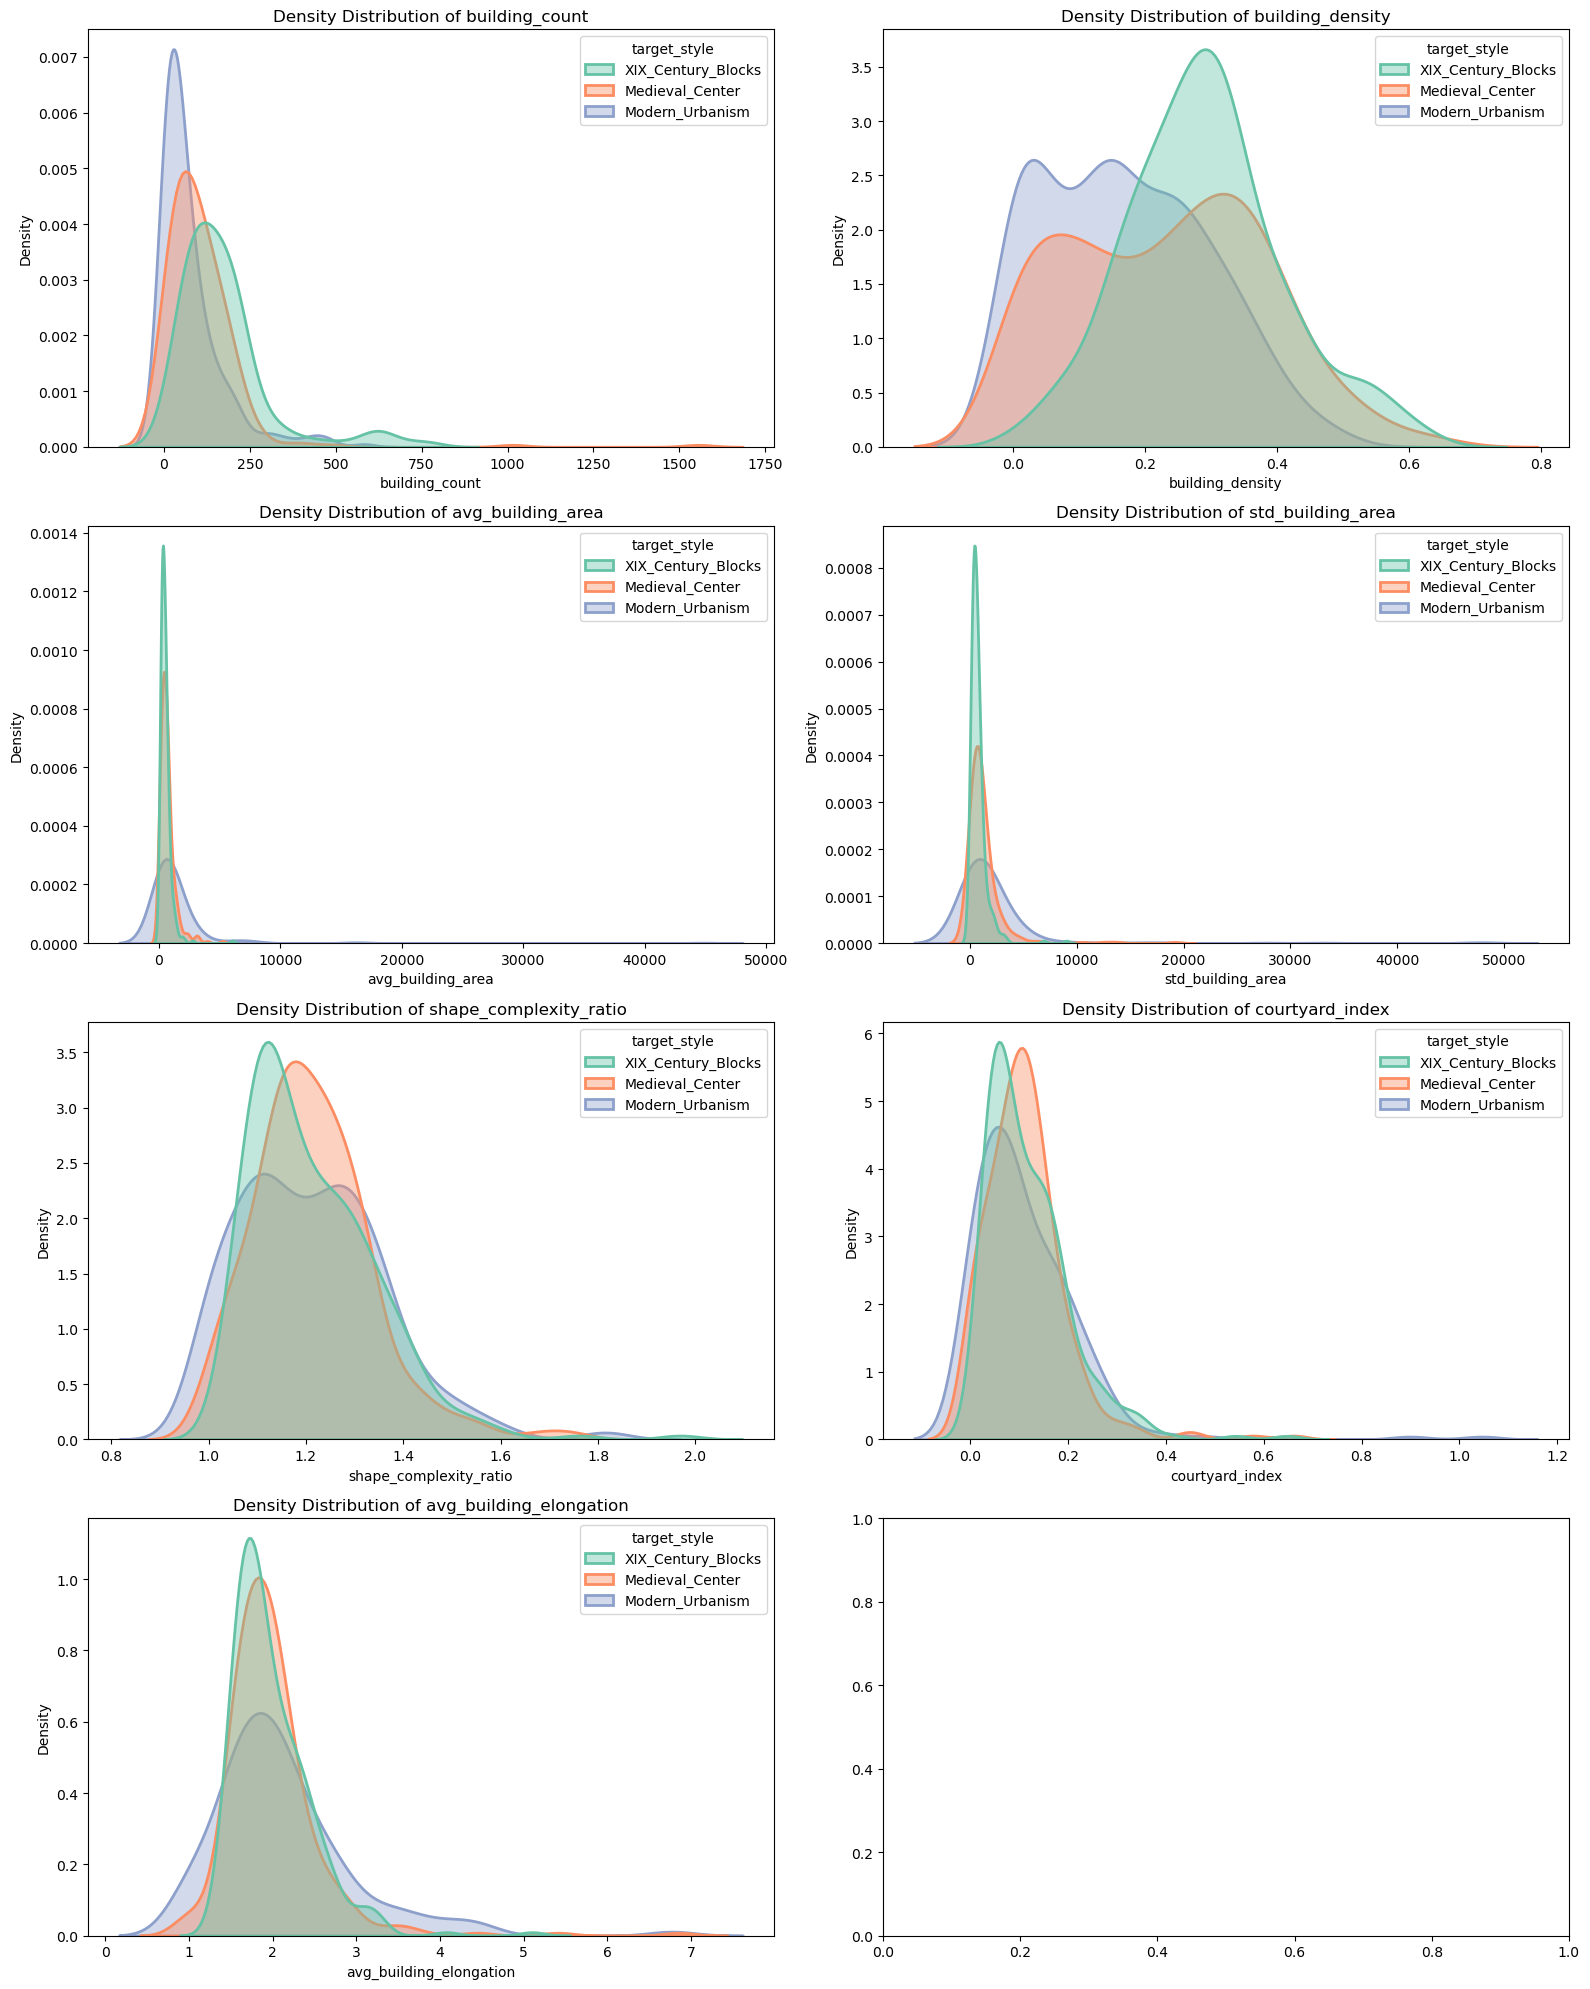

In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns
feature_cols = [
'building_count',
            'building_density',
            'avg_building_area',
            'std_building_area',
            'shape_complexity_ratio',
            'courtyard_index',
            'avg_building_elongation'
]


fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue='target_style',
        fill=True,
        common_norm=False,  # Uniezależnia wykres od różnic w liczebności klas
        alpha=0.4,
        linewidth=2,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f"Density Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()

KeyError: 'target_style'

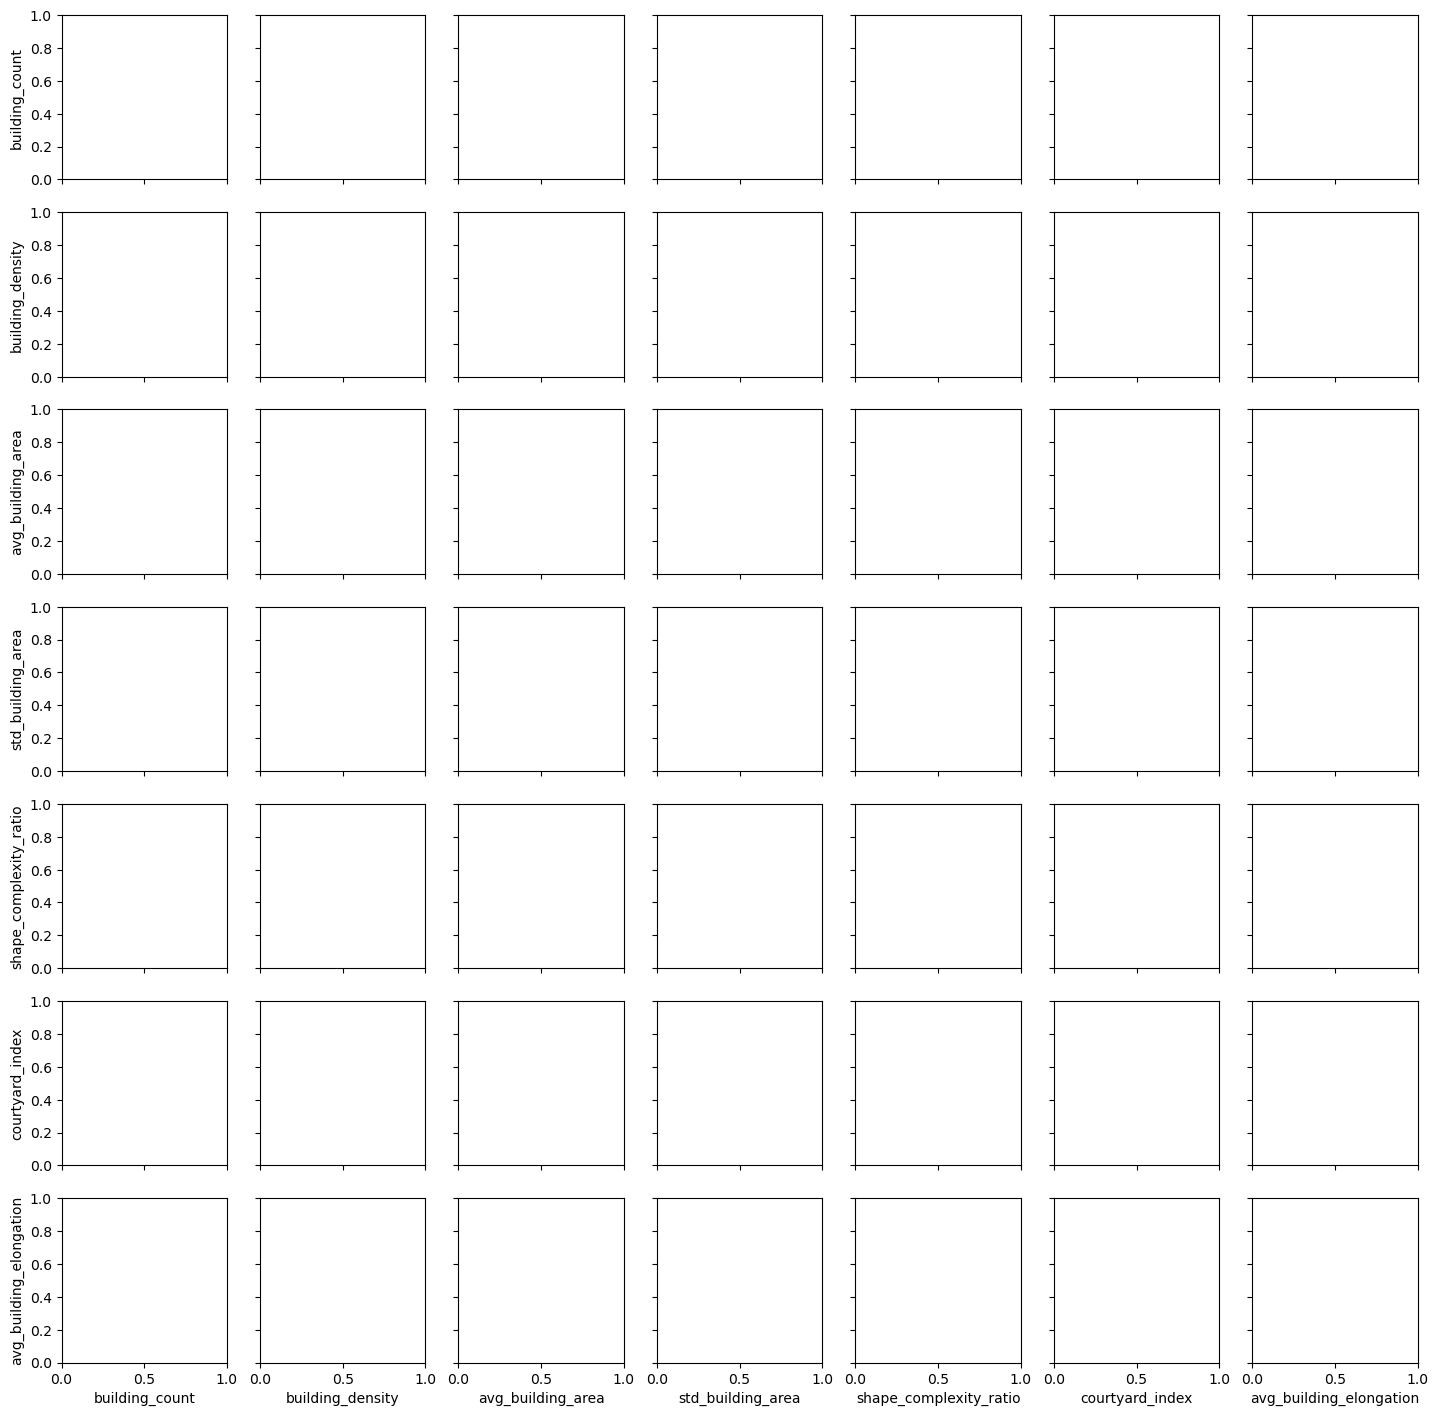

In [4]:

selected_features = ['building_density', 'shape_complexity_ratio', 'courtyard_index', 'road_density_ratio', 'target_style']


sns.pairplot(
    df[feature_cols], 
    hue='target_style', 
    palette='Set2', 
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle("Pairplot of Key Urban Features", y=1.02, fontsize=16)
plt.show()

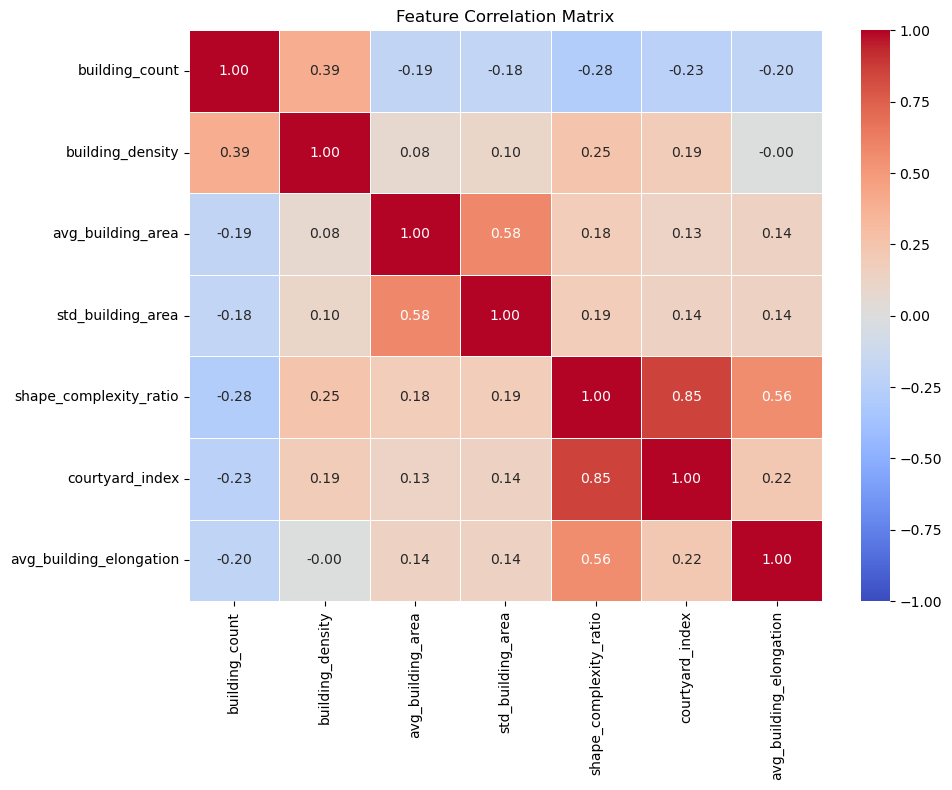

In [5]:
plt.figsize = (10, 8)

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Number of samples per class:
target_style
XIX_Century_Blocks    276
Modern_Urbanism       259
Medieval_Center       257
Name: count, dtype: int64

Percentage share per class:
target_style
XIX_Century_Blocks    34.848485
Modern_Urbanism       32.702020
Medieval_Center       32.449495
Name: proportion, dtype: float64


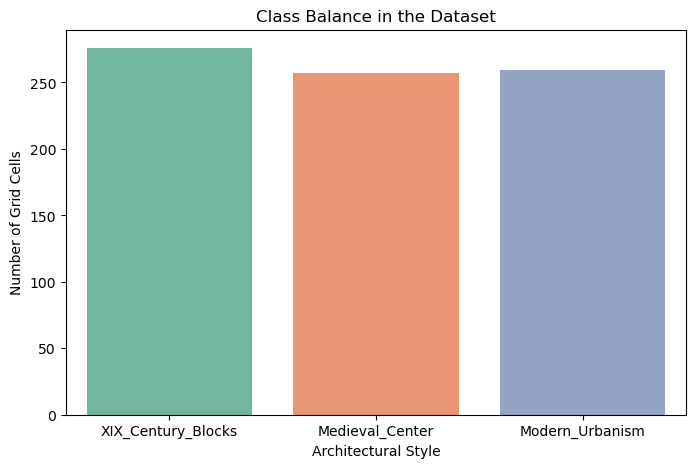

In [6]:
print("Number of samples per class:")
print(df['target_style'].value_counts())

print("\nPercentage share per class:")
print(df['target_style'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='target_style', palette='Set2', hue='target_style', legend=False)
plt.title("Class Balance in the Dataset")
plt.ylabel("Number of Grid Cells")
plt.xlabel("Architectural Style")
plt.show()